
# Optimización de Redes Neuronales

**Estudiante:** Yohan Nicolás Gómez Castañeda  
**Universidad:** Universidad de Cundinamarca  
**Programa:** Especialización en Inteligencia Artificial  
**Fecha:** 19 de marzo de 2026  

---

## Objetivo
Comparar el rendimiento de una red neuronal utilizando dos técnicas de optimización: SGD y Adam.


In [5]:

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt


## Carga de datos (MNIST)

In [6]:

from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0


## Definición del modelo

In [7]:

def crear_modelo():
    return tf.keras.models.Sequential([
        tf.keras.layers.Flatten(input_shape=(28,28)),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])


## Entrenamiento con SGD

In [8]:

model_sgd = crear_modelo()

model_sgd.compile(optimizer='sgd',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

history_sgd = model_sgd.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8437 - loss: 0.6171 - val_accuracy: 0.9071 - val_loss: 0.3527
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9062 - loss: 0.3374 - val_accuracy: 0.9198 - val_loss: 0.2918
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9182 - loss: 0.2906 - val_accuracy: 0.9264 - val_loss: 0.2609
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9264 - loss: 0.2608 - val_accuracy: 0.9333 - val_loss: 0.2365
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9336 - loss: 0.2374 - val_accuracy: 0.9368 - val_loss: 0.2189


## Entrenamiento con Adam

In [9]:

model_adam = crear_modelo()

model_adam.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

history_adam = model_adam.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9260 - loss: 0.2569 - val_accuracy: 0.9594 - val_loss: 0.1351
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9667 - loss: 0.1130 - val_accuracy: 0.9722 - val_loss: 0.0949
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9764 - loss: 0.0772 - val_accuracy: 0.9755 - val_loss: 0.0784
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9826 - loss: 0.0576 - val_accuracy: 0.9725 - val_loss: 0.0840
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9862 - loss: 0.0440 - val_accuracy: 0.9781 - val_loss: 0.0710


## Comparación

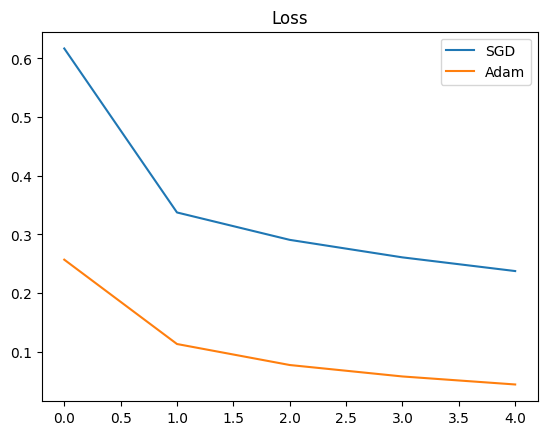

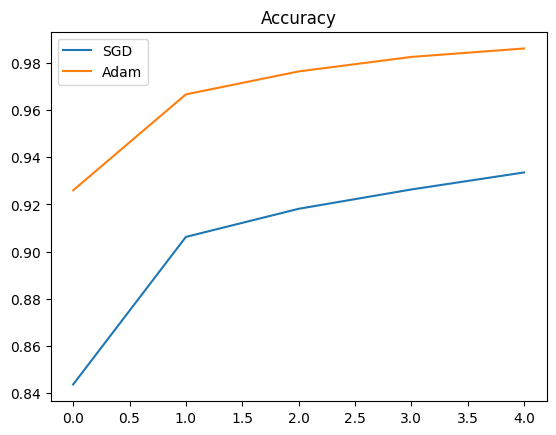

In [10]:

import matplotlib.pyplot as plt

plt.plot(history_sgd.history['loss'], label='SGD')
plt.plot(history_adam.history['loss'], label='Adam')
plt.legend()
plt.title("Loss")
plt.show()

plt.plot(history_sgd.history['accuracy'], label='SGD')
plt.plot(history_adam.history['accuracy'], label='Adam')
plt.legend()
plt.title("Accuracy")
plt.show()


### Análisis del impacto de la optimización

En este experimento se evaluó el impacto de dos optimizadores distintos SGD y Adam sobre el rendimiento de una red neuronal entrenada con el conjunto de datos MNIST.

En primer lugar, se observa que el optimizador Adam presenta una convergencia significativamente más rápida en comparación con SGD, desde las primeras épocas, la función de pérdida loss disminuye de forma más pronunciada en Adam, lo que indica que el modelo aprende de manera más eficiente.

Por otro lado, el optimizador SGD muestra un comportamiento más lento en la reducción del error, aunque eventualmente mejora, requiere un mayor número de iteraciones para alcanzar niveles de desempeño similares. Esto se debe a que SGD utiliza una tasa de aprendizaje fija, mientras que Adam ajusta automáticamente este parámetro durante el entrenamiento.

En términos de precisión accuracy, el modelo entrenado con Adam logra valores más altos en menos épocas, lo que evidencia una mejor capacidad de generalización en menor tiempo, la estabilidad del entrenamiento con Adam es mayor, mostrando menos fluctuaciones en comparación con SGD.

También es importante destacar que Adam combina ventajas de otros métodos como Momentum y RMSProp, lo que le permite adaptarse dinámicamente a la forma del espacio de optimización, evitando mínimos locales y mejorando la eficiencia del aprendizaje.

En conclusión, la implementación de la técnica de optimización Adam tiene un impacto positivo en el rendimiento del modelo, mejorando tanto la velocidad de convergencia como la precisión final, lo cual es fundamental en aplicaciones de aprendizaje automático.

### Conclusión

A partir de los resultados obtenidos, se concluye que el optimizador Adam es más eficiente que el optimizador SGD para el entrenamiento de la red neuronal utilizada en este experimento.

Adam demostró una mayor capacidad para reducir la función de pérdida en menos épocas, lo que se traduce en un proceso de entrenamiento más rápido y eficiente, alcanzó mejores niveles de precisión lo que indica una mejor capacidad de aprendizaje y generalización del modelo.

Por su parte, el optimizador SGD, aunque es más simple y ampliamente utilizado, mostró limitaciones en términos de velocidad de convergencia y estabilidad durante el entrenamiento, esto lo hace menos eficiente en comparación con Adam en este tipo de problemas.

La elección de Adam como técnica de optimización se justifica por su capacidad de ajustar automáticamente la tasa de aprendizaje, lo que permite un mejor desempeño sin necesidad de ajustes manuales complejos.

En general, este ejercicio demuestra la importancia de seleccionar adecuadamente las técnicas de optimización en el diseño de modelos de aprendizaje automático, ya que estas pueden influir significativamente en el rendimiento final del sistema.
